### Overview

We now load a time-series of high-resolution landcover maps and use them to detect landcover change. We will use the [Sentinel-2 10-Meter Land Use/Land Cover](https://www.impactobservatory.com/maps-for-good/) (2017-2024) is produced by Impact Observatory, Microsoft, and Esri.

We will pick a landcover of interest (water, trees, built-up) and find regions that have changed. We will also leverage the raster analysis functions provided by the [`xarray-spatial`](https://xarray-spatial.readthedocs.io/en/stable/index.html) to remove noise from our detection and convert the results into polygons suitable for mapping.

### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
  !pip install pystac-client odc-stac rioxarray xarray-spatial \
    dask[distributed] jupyter-server-proxy planetary_computer botocore

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import os
import dask.array as da
import geopandas as gpd
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
from affine import Affine
from matplotlib import cm
from odc import stac
from odc.geo.geobox import GeoBox
from odc.stac import load, configure_s3_access
from xrspatial.polygonize import polygonize
from xrspatial.sieve import sieve

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

Read the GeoJSON.

In [ ]:
aoi_gdf = gpd.read_file(aoi_filepath)

Extract the geometry.

In [ ]:
geometry = aoi_gdf.geometry.union_all()
geometry

### Load 10-Meter Land Use/Land Cover

The 10m Annual Land Use Land Cover (9-class) dataset is available on [Registry of Open Data on AWS](https://aws.amazon.com/marketplace/pp/prodview-vzwv5tv42fili). We use the [Impact Overvatory STAC API Endpoint](https://api.impactobservatory.com/stac-aws/) to query the matching tiles for our region.

In [ ]:
configure_s3_access(
    aws_unsigned=True,
)

catalog = pystac_client.Client.open(
    'https://api.impactobservatory.com/stac-aws/')

search = catalog.search(
    collections=['io-10m-annual-lulc'],
    intersects=geometry,
)
items = search.item_collection()
items

Each STAC item has metadata containing information about the class names, legend colors and pixel values. Let's extract it so we can use it later to contruct a meaningful legend.

In [ ]:
class_list = items[0].assets['supercell'].extra_fields['classification:classes']
class_dict = {
    c['value']: {'description': c['description'], 'hex': c['color_hint']}
    for c in class_list
    if c['value'] != 0
}
class_dict

Load the matching images as a XArray Dataset. This is a 10m resolution dataset and we load it at the native resolution.

In [ ]:
# Load to XArray
io_ds = stac.load(
    items,
    bbox=geometry.bounds, # <-- load data only for the bbox
    resolution=10,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)
io_ds

The landcover classification data is in the `supercell` variable. Select it.

In [ ]:
io_data = io_ds['supercell']
io_data

We have a time-series of landcover data for 8-years. Let's load the data into memory using `.compute()`.

In [ ]:
%%time
io_data = io_data.compute()

In [ ]:
aoi_gdf_reprojected = aoi_gdf.to_crs(io_data.rio.crs)
io_data_clipped = io_data.rio.clip(aoi_gdf_reprojected.geometry)

### Visualize Annual Land Cover

To create a meaningful legend, we use the class names and colors from the `class_dict` created earlier.

In [ ]:
io_colors = ['#000000'] * 256
for key, value in class_dict.items():
    io_colors[int(key)] = f'#{value["hex"]}'
io_colors[0] = (0, 0, 0, 0)
io_cmap = matplotlib.colors.ListedColormap(io_colors)
io_normalizer = matplotlib.colors.Normalize(vmin=0, vmax=255)

io_values = sorted(class_dict.keys())
io_boundaries = [(io_values[i + 1] + io_values[i]) / 2 for i in range(len(io_values) - 1)]
io_boundaries = [0] + io_boundaries + [255]
io_ticks = [
    (io_boundaries[i + 1] + io_boundaries[i]) / 2
    for i in range(len(io_boundaries) - 1)
]
io_tick_labels = [
    f'{class_dict[k]["description"]} ({k})'
    for k in io_values
]

Plot the annual landcover.

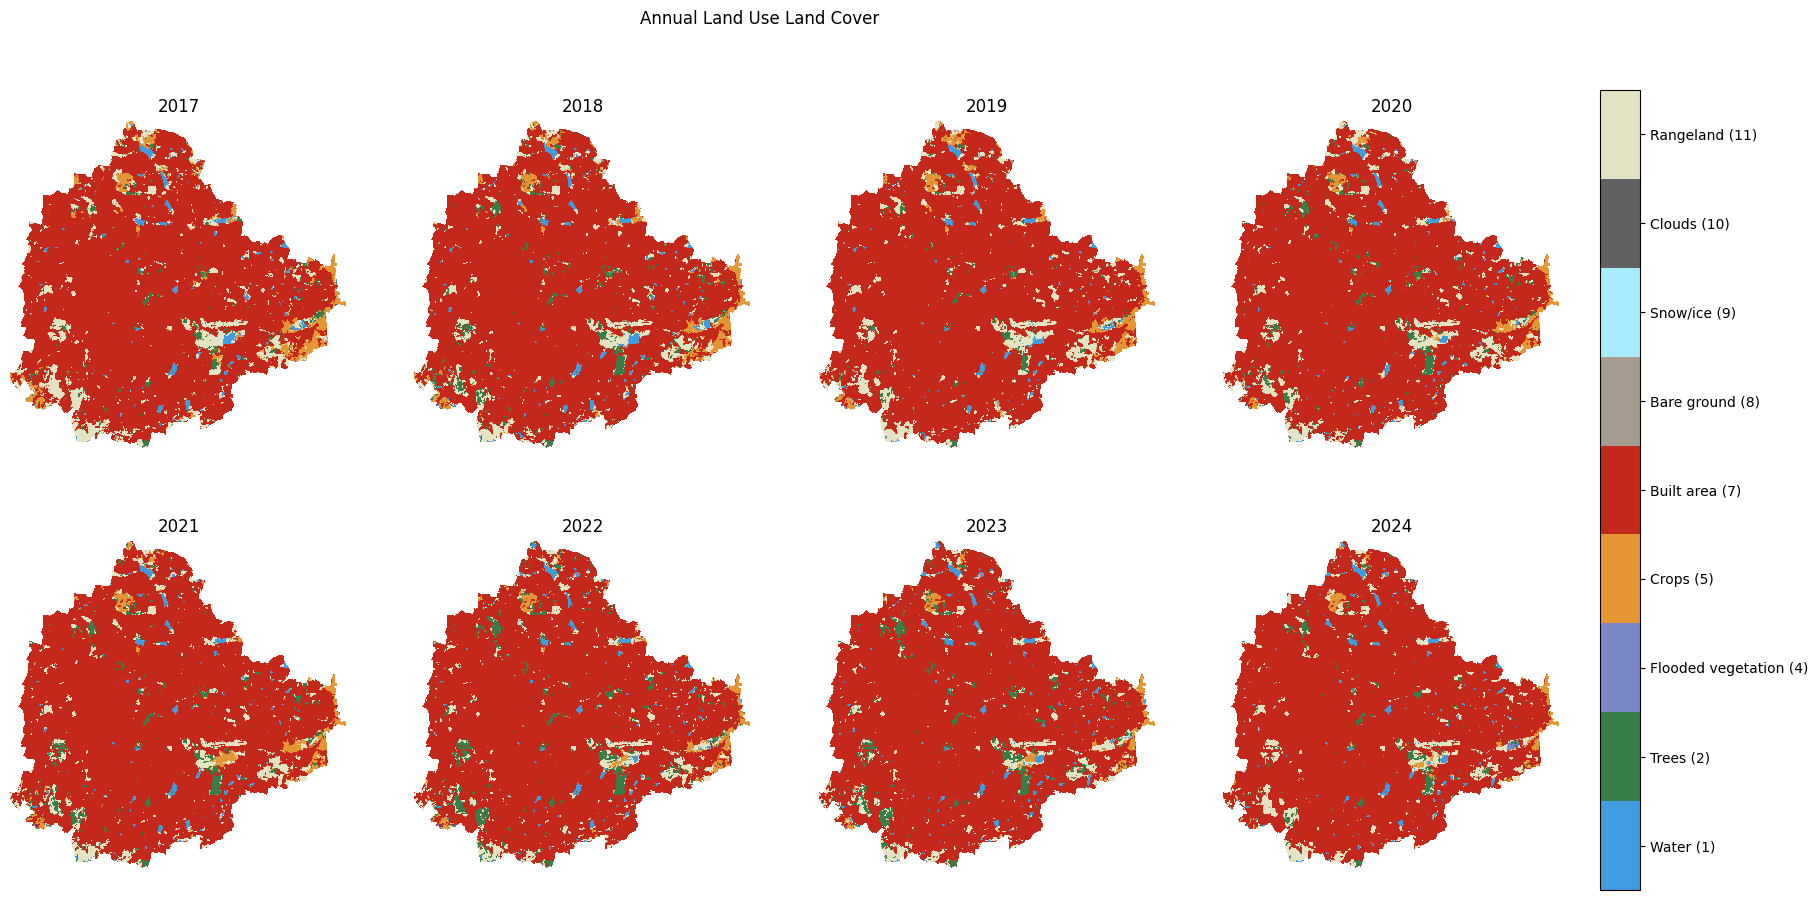

In [42]:
n_times = io_data_clipped.sizes['time']
ncols = 4
nrows = (n_times + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols)
fig.set_size_inches(20, nrows * 5)

# Create a preview
io_data_preview = io_data_clipped.rio.reproject(
    io_data_clipped.rio.crs, resolution=100)

for i, t in enumerate(io_data_preview.time.values):
    ax = axes.flat[i]
    io_data_preview.sel(time=t).plot(
        ax=ax, cmap=io_cmap, norm=io_normalizer, add_colorbar=False)
    ax.set_title(str(t)[:4])
    ax.set_axis_off()
    ax.set_aspect('equal')


for j in range(n_times, nrows * ncols):
    axes.flat[j].set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
colorbar = fig.colorbar(
    cm.ScalarMappable(norm=io_normalizer, cmap=io_cmap),
    boundaries=io_boundaries,
    values=io_values,
    cax=cbar_ax,
)
colorbar.set_ticks(io_ticks, labels=io_tick_labels)
fig.suptitle('Annual Land Use Land Cover')
plt.show()

### Analyze Change

One of the primary use cases of landcover datasets is to detect change. We can use this rich time-series data to find pixels that have changed their landcover. Select any two time-periods from the available time-series.

In [ ]:
before = io_data_clipped.sel(time='2017').squeeze()
after = io_data_clipped.sel(time='2024').squeeze()

We have pick a landcover and find the pixels which have experienced change.

Here are the pixel values in before and after images and their classes for reference.

| Pixel Value | Class Name |
|---|---|
| 1 | Water |
| 2 | Trees |
| 4 | Flooded Vegetation |
| 5 | Crops |
| 7 | Built Area |
| 8 | Bare Ground |
| 9 | Snow/Ice |
| 10 | Clouds |
| 11 | Rangeland |


In this example we try to detect and map lost waterbodies by find all pixels that were water (class 1) before and not-water (not class 1). The result is a binary image, with pixel values 1 indicating change and 0 for no change.

You can pick any landcover of your interest and build an expression for the type of change you want to detect. We have added some commented expression below as example.

In [ ]:
change = ((before == 1) & (after != 1)) # Lost waterbodies
#change = change | ((before == 2) & (after != 2)) # Loss of tree cover
#change = change | ((before != 7) & (after == 7)) # Urban growth

# Convert the boolean array to int
change = change.astype('uint8')
change

Let's visualize the results.

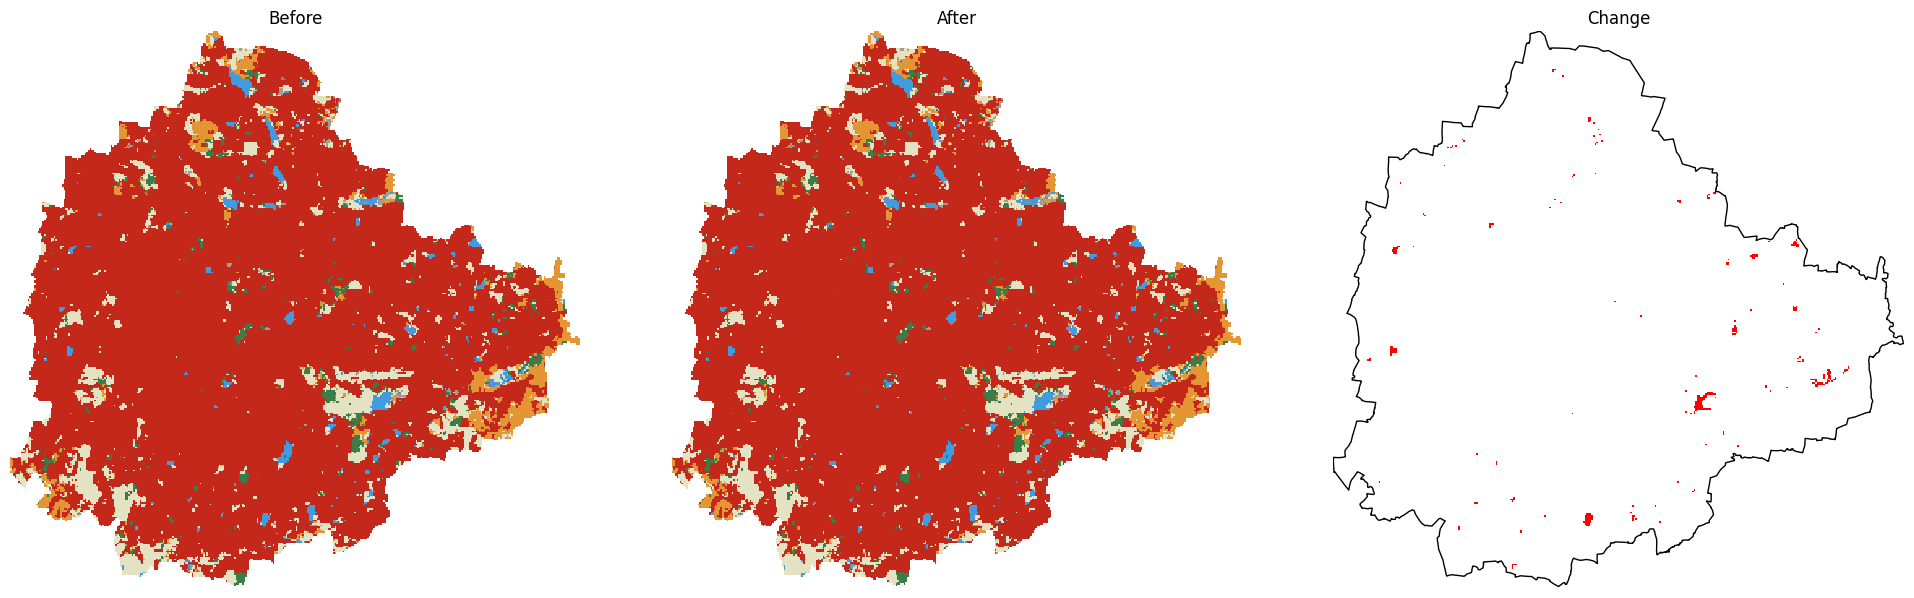

In [ ]:
fig, axes = plt.subplots(1, 3)
fig.set_size_inches(20, 6)

# Create previews
before_preview = before.rio.reproject(
    before.rio.crs, resolution=100
)
after_preview = after.rio.reproject(
    after.rio.crs, resolution=100
)
change_preview = change.rio.reproject(
    change.rio.crs, resolution=100
)

before_preview.plot(ax=axes[0], cmap=io_cmap,
                    norm=io_normalizer, add_colorbar=False)
axes[0].set_title('Before')
axes[0].set_axis_off()
axes[0].set_aspect('equal')

after_preview.plot(ax=axes[1], cmap=io_cmap,
                    norm=io_normalizer, add_colorbar=False)
axes[1].set_title('After')
axes[1].set_axis_off()
axes[1].set_aspect('equal')

change_cmap = matplotlib.colors.ListedColormap(['white', 'red'])
aoi_gdf_reprojected.boundary.plot(ax=axes[2], color='black', linewidth=1)
change_preview.plot(ax=axes[2], cmap=change_cmap, vmin=0, vmax=1, add_colorbar=False)
axes[2].set_title('Change')
axes[2].set_axis_off()
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

### Post-processing Results

Our change raster has quite a bit of noise where we have changes in individual pixels. Let's filter noise and small patches from the result using the [`xrspatial.sieve.sieve()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.sieve.sieve.html) function.

This function allows us to select only patches of contiguous pixels larger than a certain threshold.

In [ ]:
connected_pixels = 100
change_filtered = sieve(change, threshold=connected_pixels)
change_filtered

Let's visualize the results.

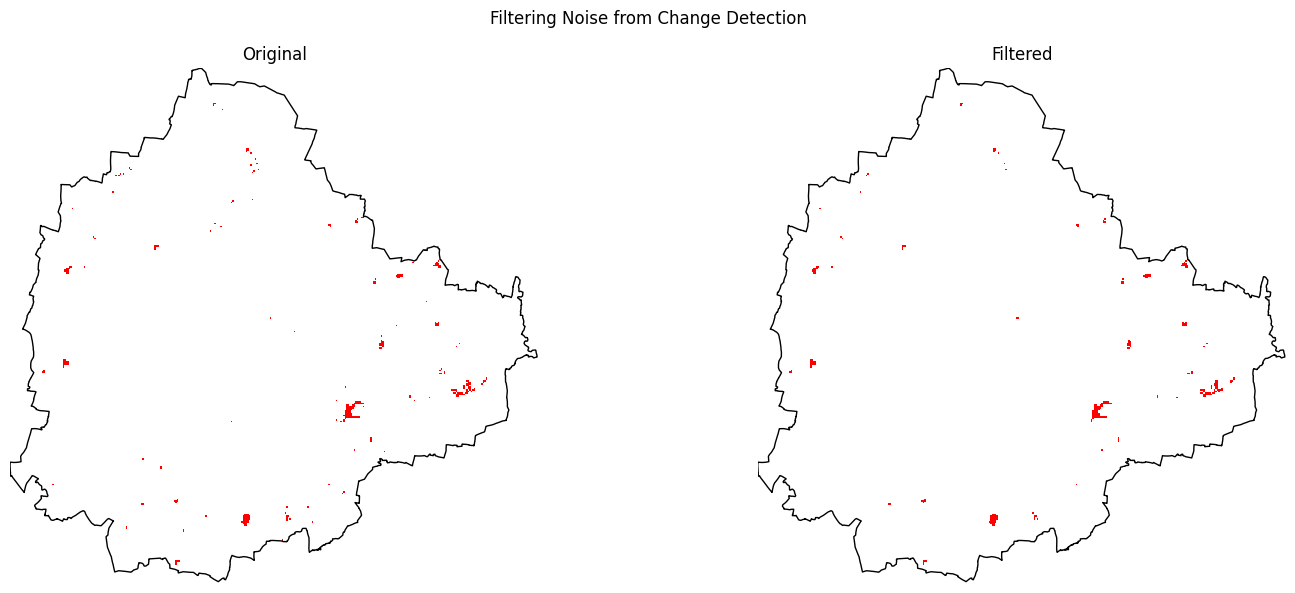

In [ ]:
change_cmap = matplotlib.colors.ListedColormap(['white', 'red'])

# Create previews
change_preview = change.rio.reproject(
    change.rio.crs, resolution=100
)
change_filtered_preview = change_filtered.rio.reproject(
    change_filtered.rio.crs, resolution=100
)

fig, axes = plt.subplots(1, 2)
fig.set_size_inches(16, 6)

change_preview.plot(ax=axes[0], cmap=change_cmap, vmin=0, vmax=1, add_colorbar=False)
aoi_gdf_reprojected.boundary.plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title('Original')
axes[0].set_axis_off()
axes[0].set_aspect('equal')

change_filtered_preview.plot(ax=axes[1], cmap=change_cmap, vmin=0, vmax=1, add_colorbar=False)
aoi_gdf_reprojected.boundary.plot(ax=axes[1], color='black', linewidth=1)
axes[1].set_title('Filtered')
axes[1].set_axis_off()
axes[1].set_aspect('equal')

fig.suptitle('Filtering Noise from Change Detection')
plt.tight_layout()
plt.show()

It will be useful to group the contiguous pixels of change and obtain polygons for use in mapping. We use the [`xrspatial.polygonize.polygonize`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.polygonize.polygonize.html) function for Xarray Spatial to convert the XArray DataArray to a GeoPandas GeoDataFrame.

In [ ]:
polygons = polygonize(change_filtered, return_type='geopandas')
polygons

We have polygons for both *change* (DN==1) and *no-change* (DN==0). Let's select only the change polygons.

In [ ]:
change_gdf = polygons[polygons['DN'] == 1]
change_gdf

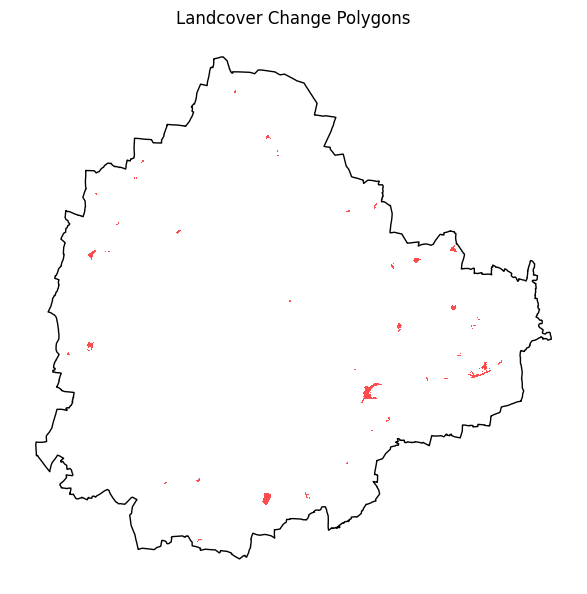

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Plot the AOI boundary
aoi_gdf_reprojected.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot the change polygons
change_gdf.plot(ax=ax, color='red', alpha=0.7)

ax.set_title('Landcover Change Polygons')
ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Save the results as a GeoPackage file.

In [ ]:
output_path = os.path.join(output_folder, 'landcover_change.gpkg')
change_gdf.to_file(output_path)
print(f'Wrote {output_path}')

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()

### Exercise

Polygons derived from classified raster data have unnatural pixelated edges. These are not suitable for use in mapping. [Smoothify](https://github.com/DPIRD-DMA/Smoothify) is a Python-package designed to convert these jagged features to smooth natural looking polygnos. Apply the `smoothify` function to your change polygons and create a smoothed version. You can review the [Usage Examples](https://github.com/DPIRD-DMA/Smoothify/blob/main/examples/usage_examples.ipynb) for explanations of parameters and advanced usage.

Save the results as `landcover_change_smoothed.gpkg`.

In [ ]:
if environment in ['colab', 'colab_enterprise']:
    !pip install smoothify

In [ ]:
from smoothify import smoothify
smoothed_gdf = smoothify(
    geom=change_gdf,
    smooth_iterations=3,  # More iterations = smoother result
    num_cores=4  # Use parallel processing for large datasets
)